**What is XGBoost?**

XGBoost (Extreme Gradient Boosting) is a highly optimized implementation of gradient boosting designed for speed and performance. It is widely used in machine learning competitions and real-world applications due to its high accuracy and scalability.

**Problem Type**

This notebook demonstrates **Regression**, where the goal is to predict a continuous numeric value.

**Real-World Applications**

XGBoost regression is commonly used in:

- House price prediction
- Stock market forecasting
- Demand forecasting
- Energy consumption prediction
- Sales prediction
- Risk modeling

**Why XGBoost?**

XGBoost provides:

- High predictive power
- Regularization to prevent overfitting
- Built-in feature importance
- Parallel processing
- Handling of missing values

**Importing Libraries**

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Feature importance
from sklearn.inspection import permutation_importance

# XGBoost
from xgboost import XGBRegressor

# Model persistence
import joblib

# Explainability
import shap

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Load dataset**

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

In [3]:
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name="target")

In [4]:
print("Dataset Shape:", X.shape)

Dataset Shape: (20640, 8)


**Exploratory Data Analysis (EDA)**

In [5]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: target, dtype: float64

In [7]:
# Statistical Summary
print(housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [8]:
# Check missing values
print(X.isnull().sum())

# No missing values in this dataset

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


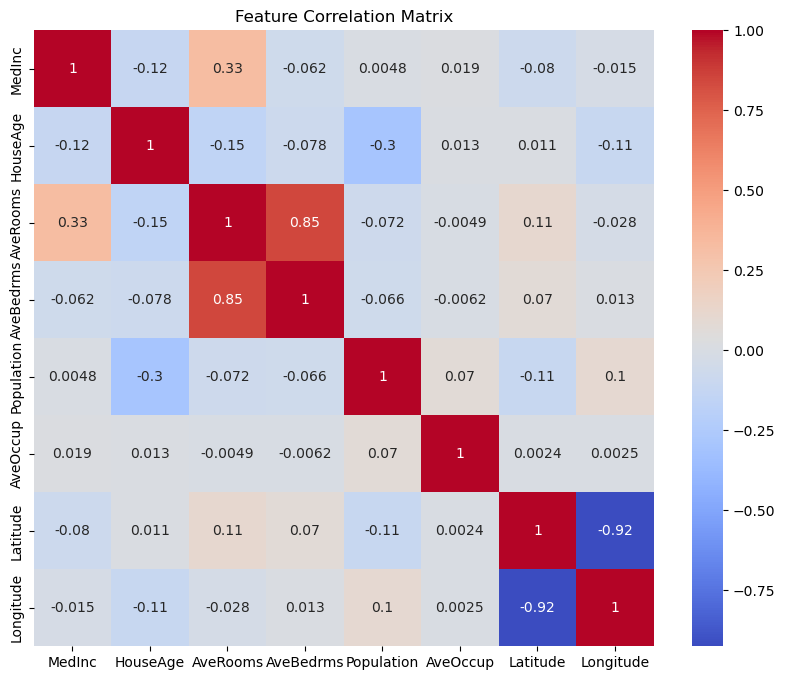

In [9]:
# Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

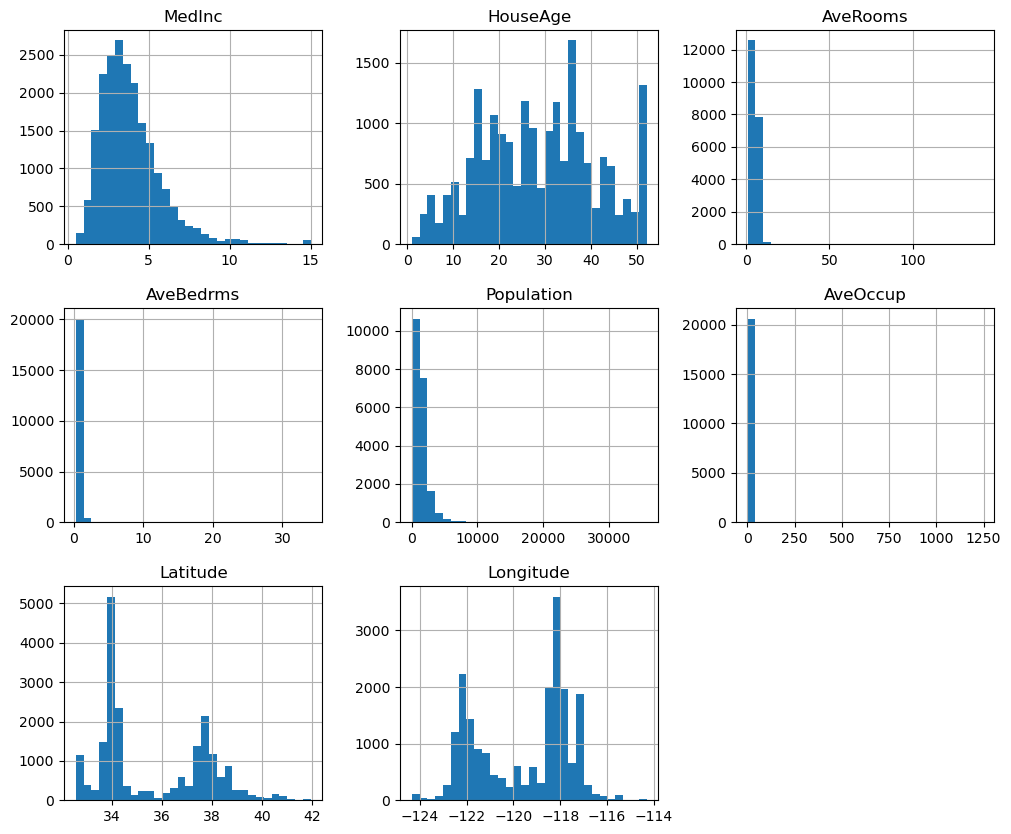

In [10]:
# Feature Distributions
X.hist(figsize=(12,10), bins=30)
plt.show()

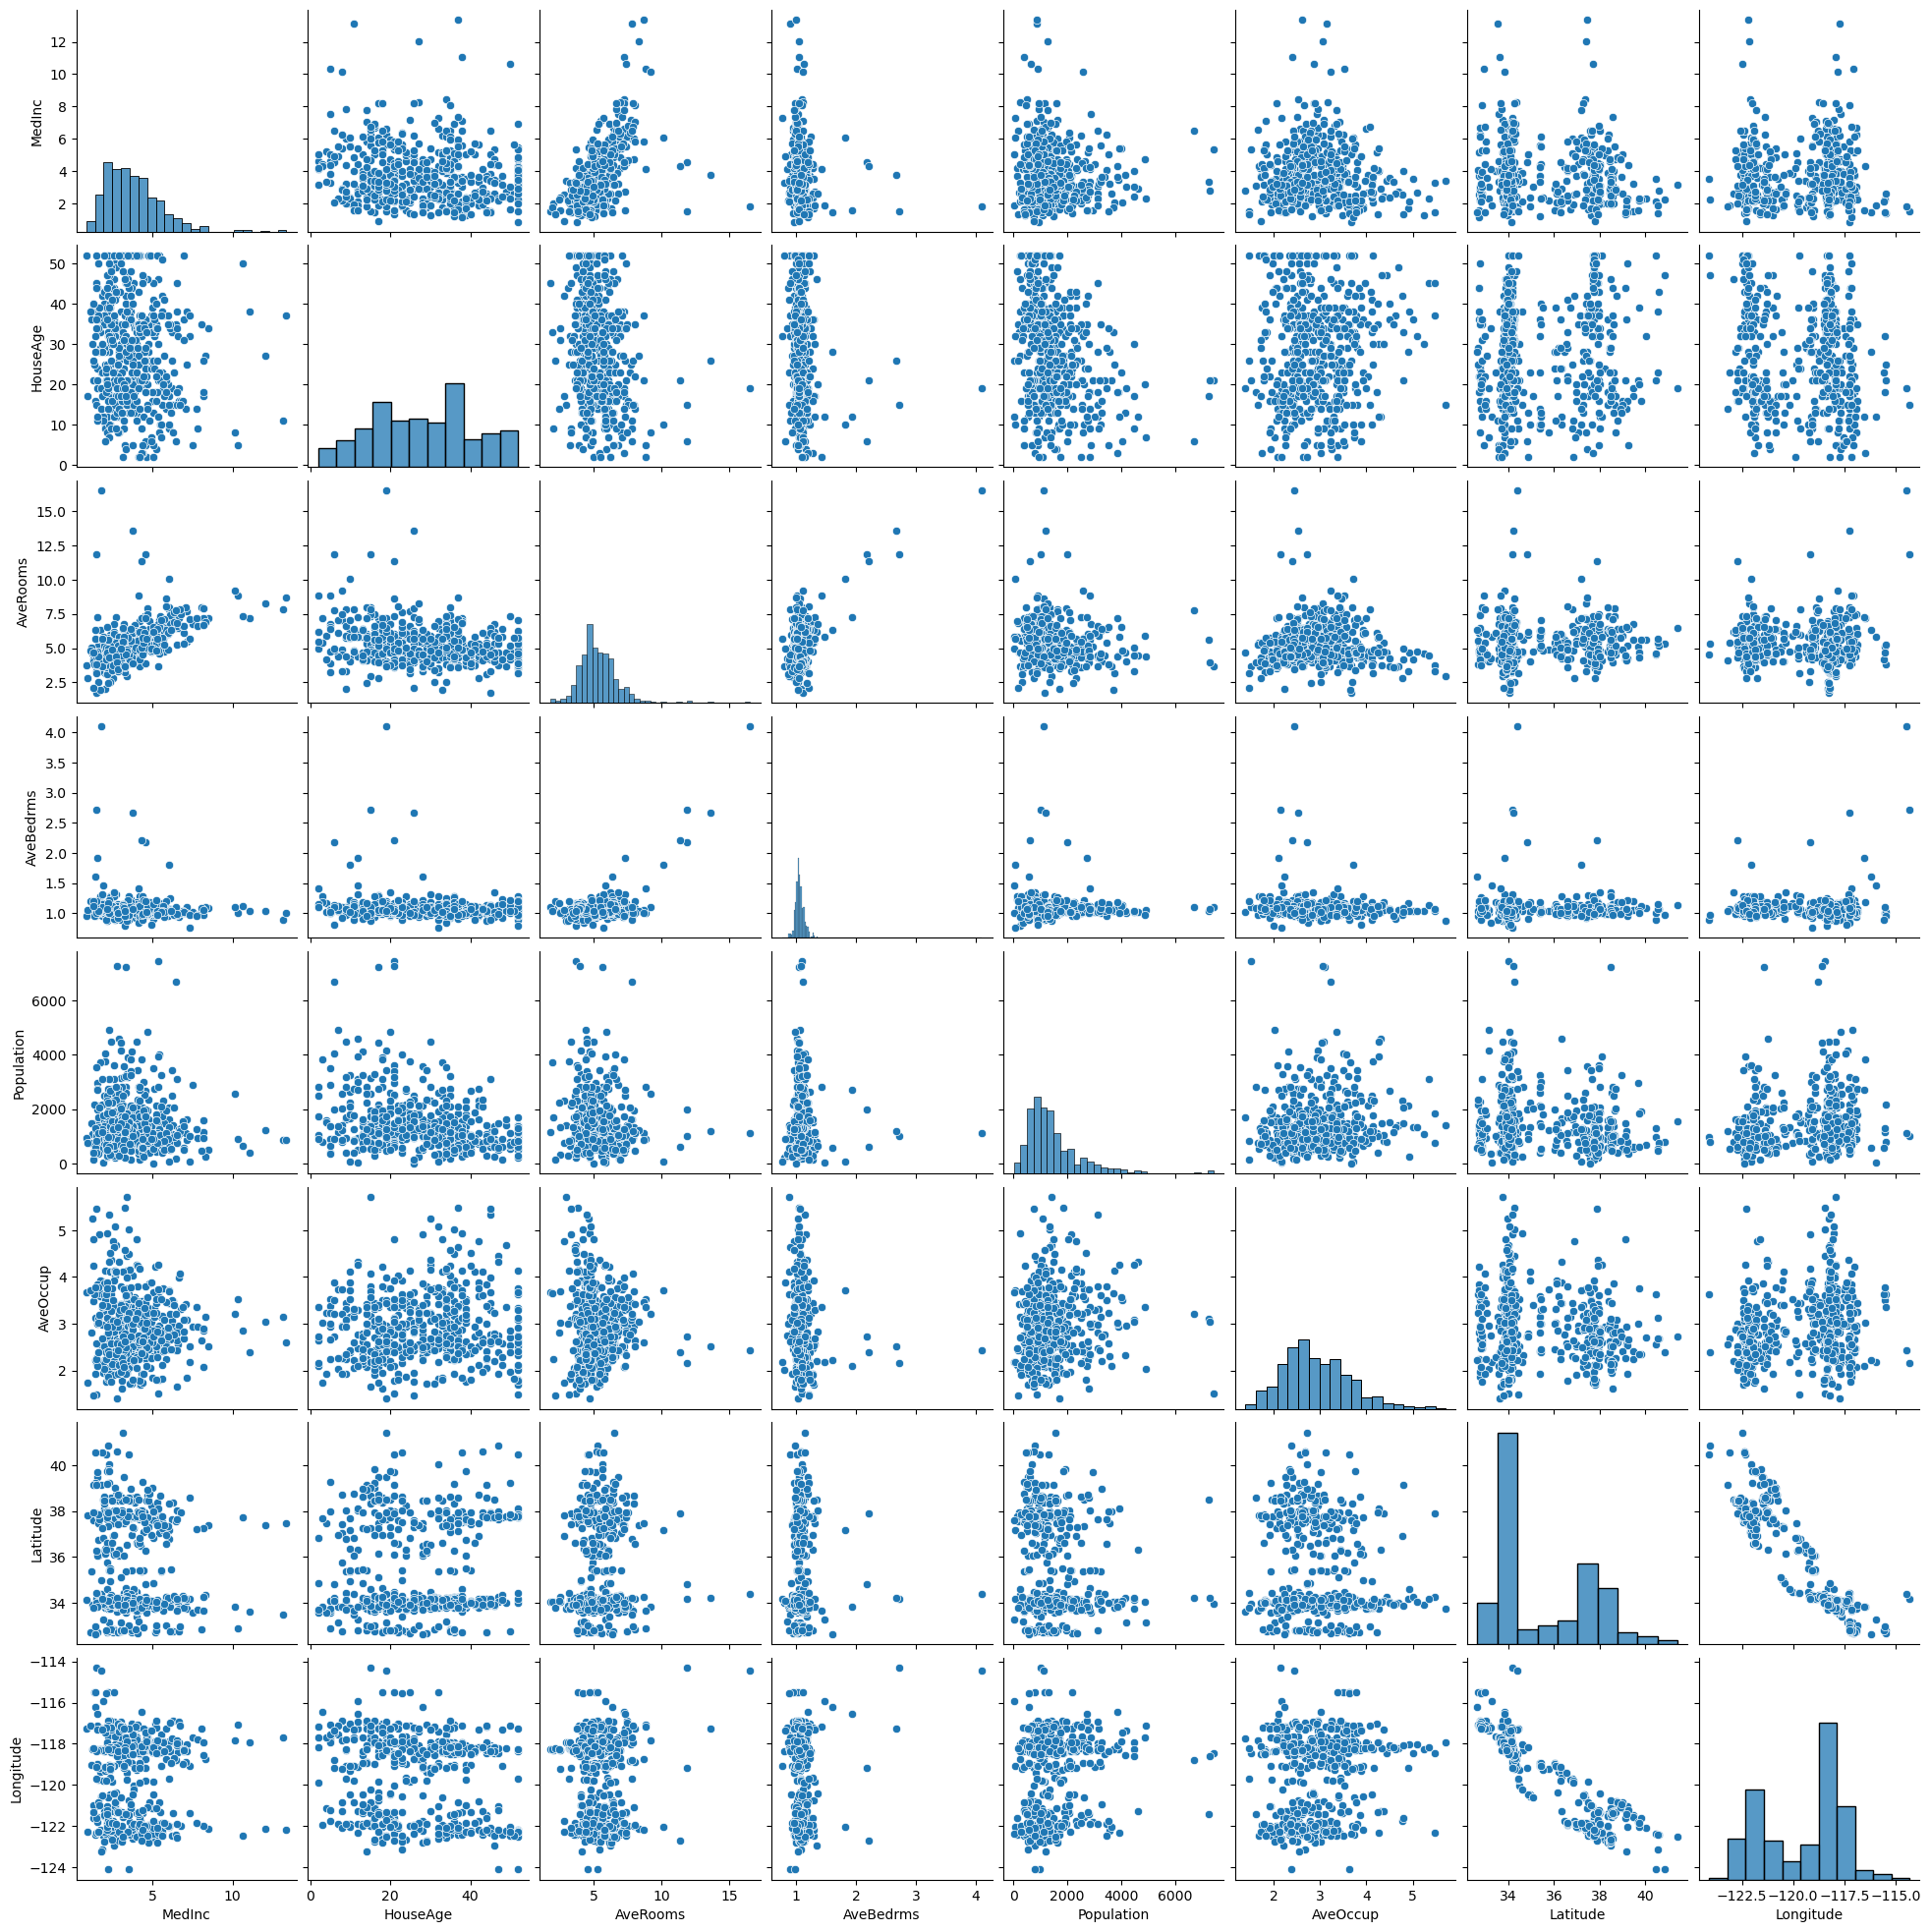

In [11]:
# Pairplot (sample)
sample_data = X.sample(500)

sns.pairplot(sample_data)
plt.show()

**Data Preprocessing**

In [12]:
scaler = StandardScaler()

**Feature Engineering**

In [13]:
X["Rooms_per_household"] = X["AveRooms"] / X["HouseAge"]

**Train-Test Split**

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 16512, Test samples: 4128


**Machine Learning Pipeline**

In [16]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ))
])

**Model Training**

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

**Hyperparameter Tuning with GridSearchCV**

In [ ]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__subsample": [0.8, 1],
    "model__colsample_bytree": [0.8, 1]
}

In [ ]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

In [ ]:
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

**Model Evaluation**

In [ ]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

**Feature Importance Visualization**

In [ ]:
model = best_model.named_steps["model"]
importance = model.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance")
plt.show()

**Learning Curve**

In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [ ]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

In [ ]:
plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, test_mean, label="Validation Score")

plt.legend()
plt.title("Learning Curve")
plt.show()

**Residual Plot**

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [ ]:
shap.plots.bar(shap_values)

In [ ]:
joblib.dump(best_model, "xgboost_regression_model.pkl")

print("Model saved successfully")

### Model Theory: XGBoost

#### 1. Algorithm Overview

XGBoost is based on **Gradient Boosting**, where models are built sequentially.

Each new tree learns from the **errors of previous trees**.

Final prediction:

$$
\hat{y} = \sum_{k=1}^{K} f_k(x)
$$

where:

* (f_k) is a decision tree
* (K) is number of trees


#### 2. Mathematical Intuition

XGBoost minimizes:

$$
Loss + Regularization
$$

$$
L = \sum l(y_i, \hat{y}_i) + \sum \Omega(f_k)
$$

Regularization prevents overfitting.



#### 3. When to Use XGBoost

Use when:

* Dataset is **structured/tabular**
* Non-linear relationships exist
* High predictive accuracy is required
* Medium to large datasets


#### 4. Advantages

* Very high accuracy
* Handles missing values
* Built-in regularization
* Fast training
* Feature importance


#### 5. Disadvantages

* Many hyperparameters
* Can overfit small datasets
* Not ideal for images/text (deep learning better)
